<a href="https://colab.research.google.com/github/oscmoral/Programacion-para-analitica-descriptiva-y-predictiva/blob/main/Evaluacion2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Etapa 2: EDA

Nombre: Oscar Morales Martinez

Materia: Programación para analítica descriptiva y predictiva

Carrera: Maestría en Inteligencia Artificial y Analítica de Datos

## 1. Descripción del dataset

- **Nombre**: Steam Store Games
- **Fuente**: Kaggle
- **Enlace**: https://www.kaggle.com/datasets/nikdavis/steam-store-games

### Importación de librerias

In [44]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Configuracion de estilos

In [45]:
sns.set_theme(style="whitegrid", context="talk")

sns.set_palette("deep")

plt.rcParams['figure.figsize'] = (10, 6)

sns.despine()

<Figure size 1000x600 with 0 Axes>

### Acceso a Google Drive

In [46]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Declaración de la ruta del archivo steam.csv

In [47]:
path = "/content/drive/MyDrive/ProjectFiles/steam.csv"

### Cargar dataset

In [48]:
df = pd.read_csv(path)

### Número de observaciones y variables

* Número de observaciones: 27075
* Número de variables: 18

In [49]:
df.shape

(27075, 18)

### Tipo de datos

Datos estructurados en formato CSV que contienen información sobre videojuegos publicados en la plataforma Steam.

Incluye variables:

- **Numéricas** (precio, puntuación Metacritic, número de recomendaciones)

- **Categóricas** (género, desarrollador, publisher)

- **Temporales** (fecha de lanzamiento)

In [50]:
df.info()

numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categoricas = df.select_dtypes(include=['object']).columns.tolist()

print("\n")
print("Variables numéricas:")
print(numericas)

print("\nVariables categóricas:")
print(categoricas)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27075 entries, 0 to 27074
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   appid             27075 non-null  int64  
 1   name              27075 non-null  object 
 2   release_date      27075 non-null  object 
 3   english           27075 non-null  int64  
 4   developer         27074 non-null  object 
 5   publisher         27061 non-null  object 
 6   platforms         27075 non-null  object 
 7   required_age      27075 non-null  int64  
 8   categories        27075 non-null  object 
 9   genres            27075 non-null  object 
 10  steamspy_tags     27075 non-null  object 
 11  achievements      27075 non-null  int64  
 12  positive_ratings  27075 non-null  int64  
 13  negative_ratings  27075 non-null  int64  
 14  average_playtime  27075 non-null  int64  
 15  median_playtime   27075 non-null  int64  
 16  owners            27075 non-null  object

## 2. Revisión de calidad de datos

### Valores faltantes

In [51]:
df.isnull().sum().sort_values(ascending=False)

,0
publisher,14
developer,1
name,0
appid,0
english,0
release_date,0
platforms,0
required_age,0
categories,0
genres,0


### Valores duplicados

In [52]:
df.duplicated().sum()

np.int64(0)

### Tipos de datos incorrectos

In [53]:
df.dtypes

,0
appid,int64
name,object
release_date,object
english,int64
developer,object
publisher,object
platforms,object
required_age,int64
categories,object
genres,object


### Nombres de columnas inconsistentes

In [54]:
df.columns

Index(['appid', 'name', 'release_date', 'english', 'developer', 'publisher',
       'platforms', 'required_age', 'categories', 'genres', 'steamspy_tags',
       'achievements', 'positive_ratings', 'negative_ratings',
       'average_playtime', 'median_playtime', 'owners', 'price'],
      dtype='object')

## 3. Preprocesamiento de datos

### Datos faltantes

In [55]:
df.isnull().sum().sort_values(ascending=False)

,0
publisher,14
developer,1
name,0
appid,0
english,0
release_date,0
platforms,0
required_age,0
categories,0
genres,0


### Aplicar metodo de eliminacion para datos faltantes

In [56]:
df = df.dropna()

df.isnull().sum().sort_values(ascending=False)

,0
appid,0
name,0
release_date,0
english,0
developer,0
publisher,0
platforms,0
required_age,0
categories,0
genres,0


### Outliers

<Axes: xlabel='price'>

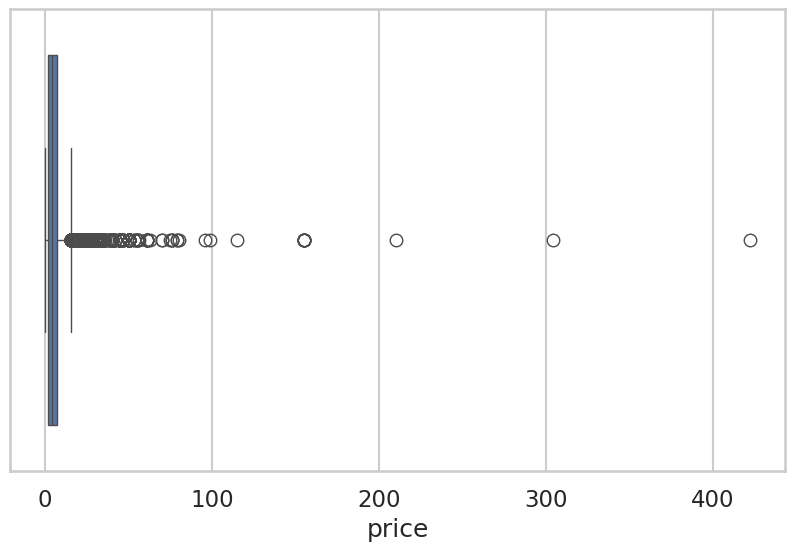

In [57]:
sns.boxplot(x=df['price'])

### Transformación de variables

### Tipos de datos fecha (transformación de variables temporales)

In [58]:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year

### Variables categoricas (multi label)

In [59]:
df['genres'] = df['genres'].str.split(';')
df['categories'] = df['categories'].str.split(';')
df['steamspy_tags'] = df['steamspy_tags'].str.split(';')

df_genres = df.explode('genres')
df_categories = df.explode('categories')
df_tags = df.explode('steamspy_tags')

## 4. Análisis univariado

### estadística descriptiva

In [60]:
df.describe()

,appid,release_date,english,required_age,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,price,year
count,2.706100e+04,27061,27061.000000,27061.000000,27061.000000,2.706100e+04,27061.000000,27061.000000,27061.000000,27061.000000,27061.000000
mean,5.962192e+05,2016-12-31 13:51:40.062821120,0.981117,0.355087,45.270278,1.001042e+03,211.120579,149.847197,146.095821,6.079350,2016.498023
min,1.000000e+01,1997-06-30 00:00:00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,1997.000000
25%,4.012100e+05,2016-04-04 00:00:00,1.000000,0.000000,0.000000,6.000000e+00,2.000000,0.000000,0.000000,1.690000,2016.000000
50%,5.990900e+05,2017-08-08 00:00:00,1.000000,0.000000,7.000000,2.400000e+01,9.000000,0.000000,0.000000,3.990000,2017.000000
75%,7.987900e+05,2018-06-07 00:00:00,1.000000,0.000000,23.000000,1.260000e+02,42.000000,0.000000,0.000000,7.190000,2018.000000
max,1.069460e+06,2019-05-01 00:00:00,1.000000,18.000000,9821.000000,2.644404e+06,487076.000000,190625.000000,190625.000000,421.990000,2019.000000
std,2.509174e+05,NaN,0.136115,2.406653,352.760212,1.899362e+04,4286.044728,1827.507970,2354.486857,7.876308,2.157347


### Histogramas

<Axes: >

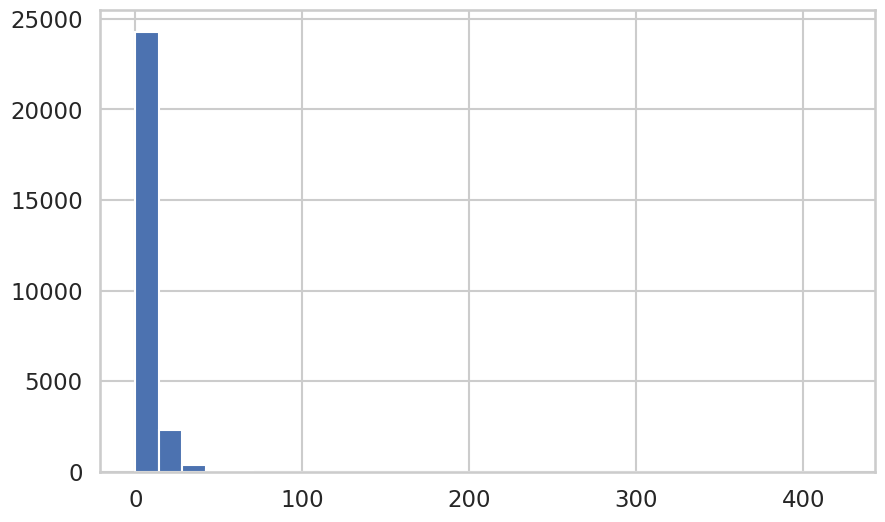

In [61]:
df['price'].hist(bins=30)

### Boxplot

<Axes: xlabel='price'>

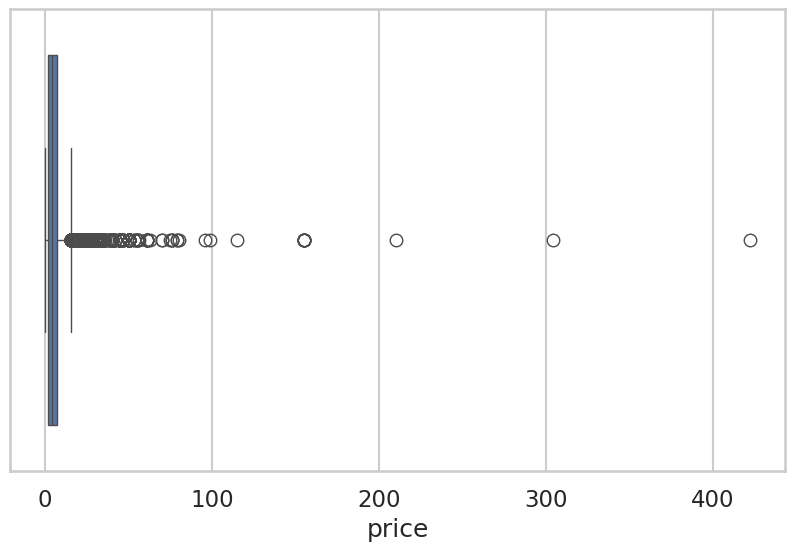

In [62]:
sns.boxplot(x=df['price'])

### Gráfica de barras (categorías)

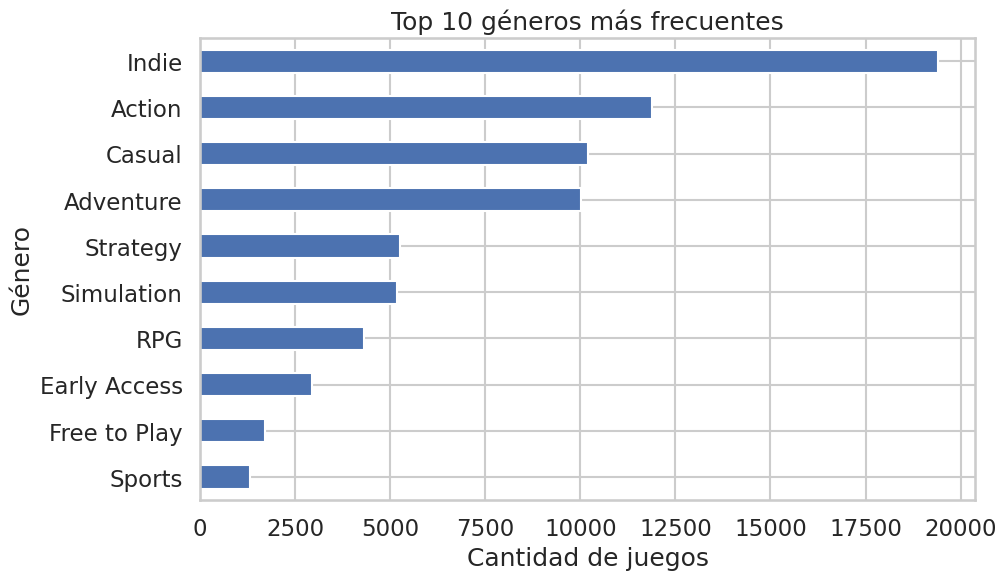

In [63]:
df_genres['genres'].value_counts().head(10).sort_values().plot(kind='barh')

plt.title('Top 10 géneros más frecuentes')
plt.xlabel('Cantidad de juegos')
plt.ylabel('Género')
plt.show()

## 5. Análisis bivariado

### Scatter Plot (precio vs popularidad)

<Axes: xlabel='price', ylabel='positive_ratings'>

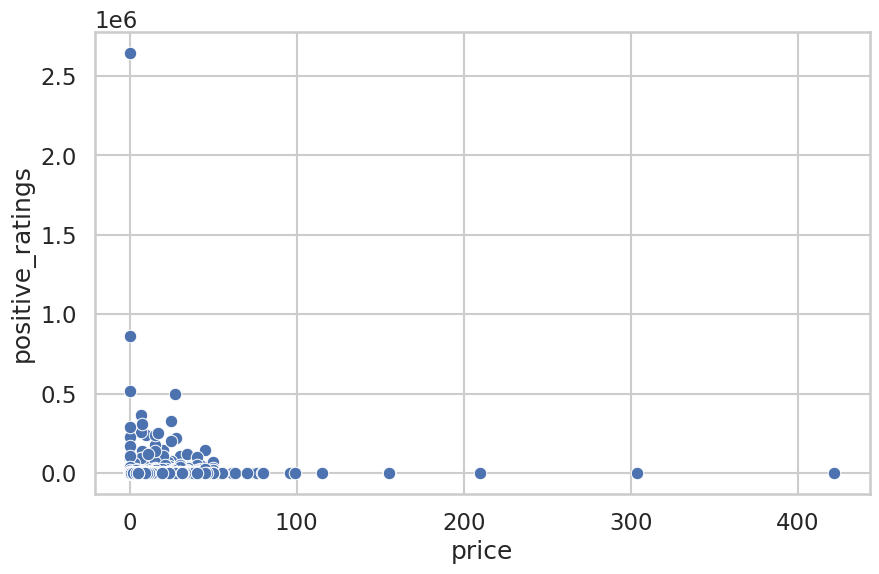

In [64]:
sns.scatterplot(x='price', y='positive_ratings', data=df)

### Boxplot (popularidad por género)

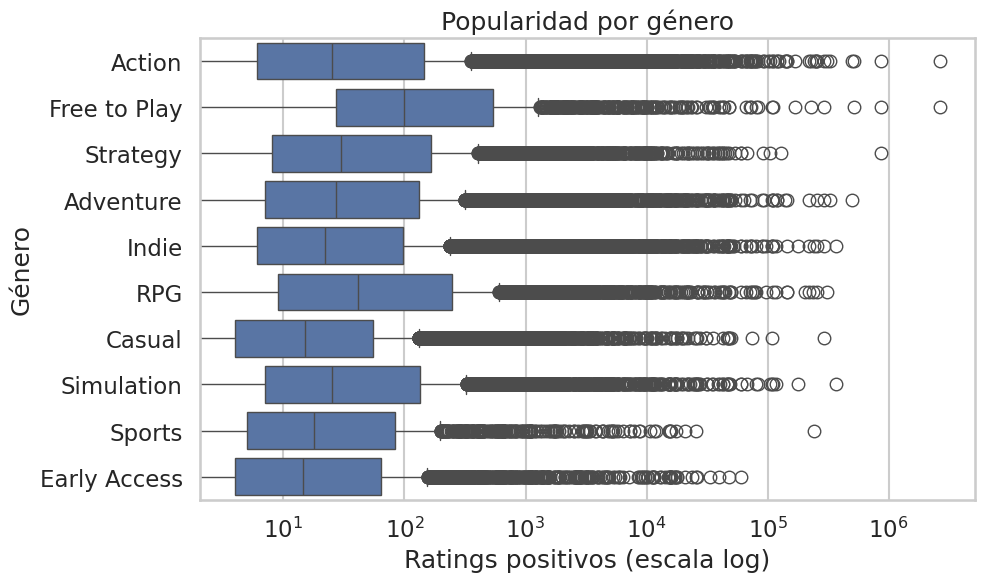

In [65]:
top_genres = df_genres['genres'].value_counts().head(10).index

sns.boxplot(
    y='genres',
    x='positive_ratings',
    data=df_genres[df_genres['genres'].isin(top_genres)]
)

plt.xscale('log')
plt.title('Popularidad por género')
plt.xlabel('Ratings positivos (escala log)')
plt.ylabel('Género')

plt.show()

### Matriz de correlación

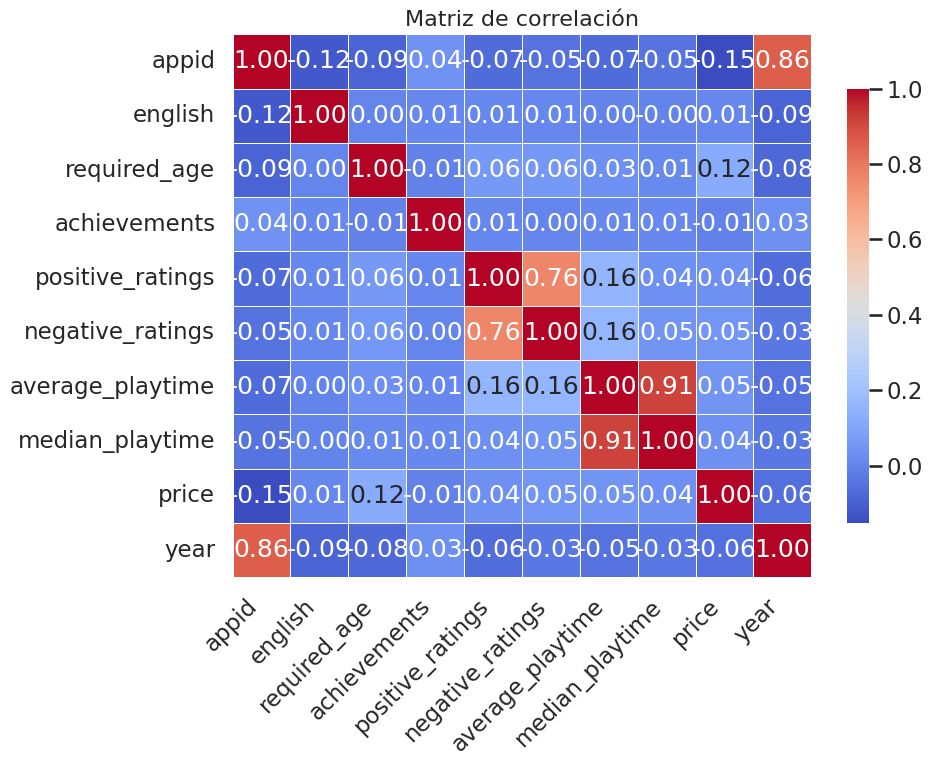

In [66]:
plt.figure(figsize=(10, 8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    linecolor='white',
    cbar_kws={"shrink": 0.8}
)

plt.title('Matriz de correlación', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## Análisis multivariado

### Pairplot

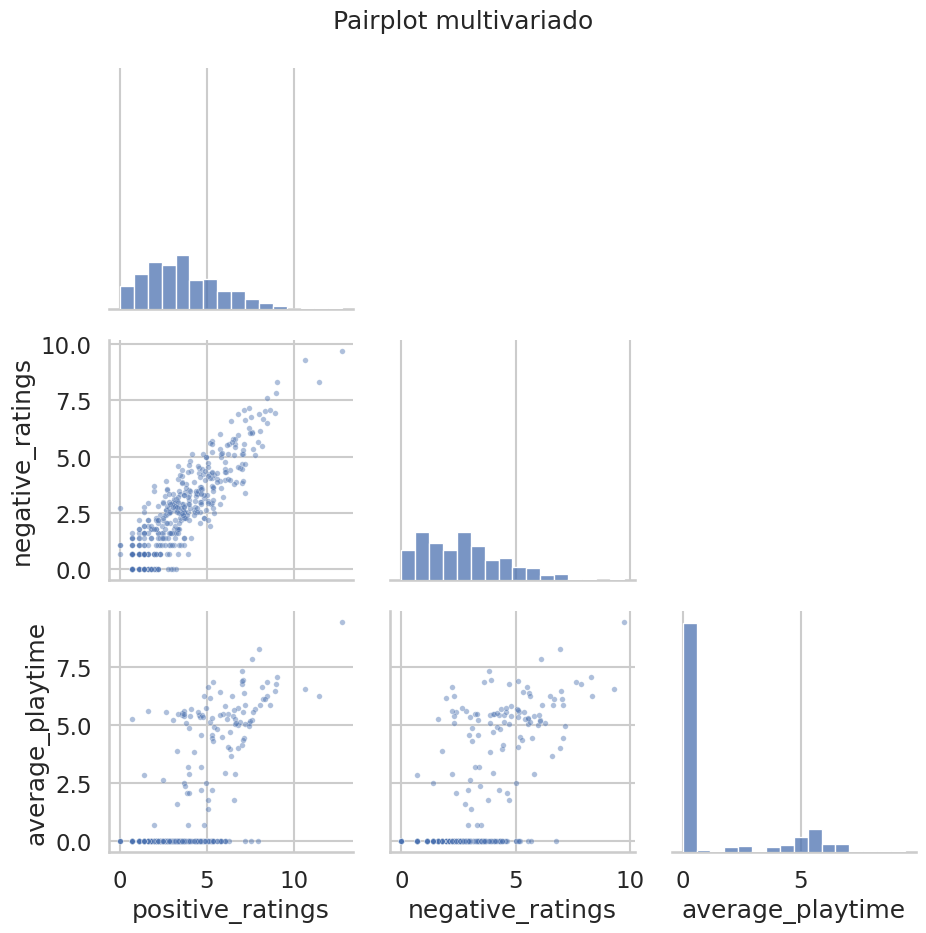

In [67]:
cols = ['positive_ratings', 'negative_ratings', 'average_playtime']
df_sample = df[cols].sample(400, random_state=42).copy()

for col in cols:
    df_sample[col] = np.log1p(df_sample[col])

g = sns.pairplot(
    df_sample,
    corner=True,
    height=3.2,
    plot_kws={'s': 16, 'alpha': 0.45},
    diag_kws={'bins': 16}
)

g.fig.suptitle('Pairplot multivariado', fontsize=18)
plt.tight_layout()
plt.show()

## 7. Visualizaciones para responder preguntas

### 1. ¿Qué géneros están más asociados con mayor popularidad?

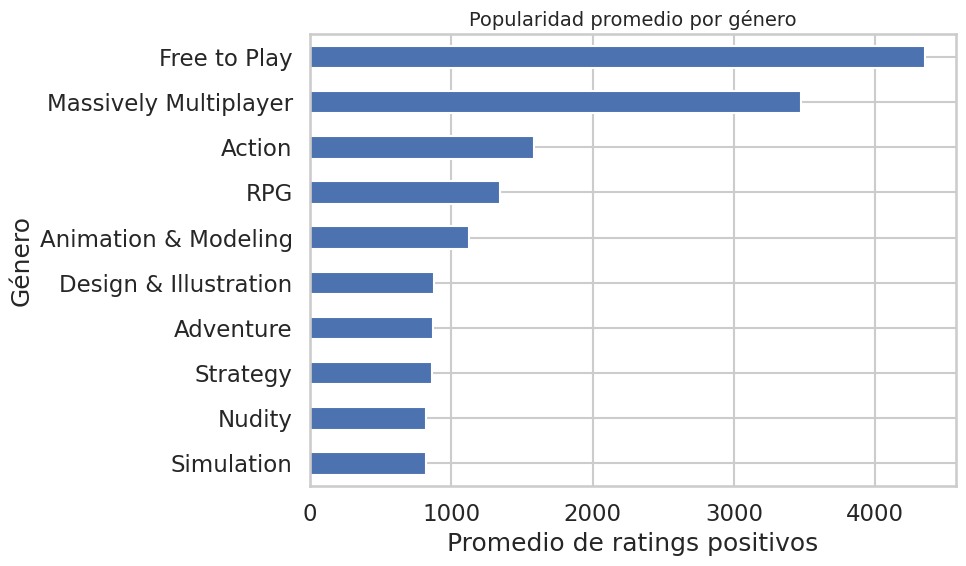

In [68]:
top_genres = df_genres.groupby('genres')['positive_ratings'] \
    .mean() \
    .sort_values(ascending=True) \
    .tail(10)

top_genres.plot(kind='barh')

plt.title('Popularidad promedio por género', fontsize=14)
plt.xlabel('Promedio de ratings positivos')
plt.ylabel('Género')

plt.tight_layout()
plt.show()

### 2. ¿Los juegos multijugador presentan mayor popularidad que los de un solo jugador?

/tmp/ipykernel_10867/747220758.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


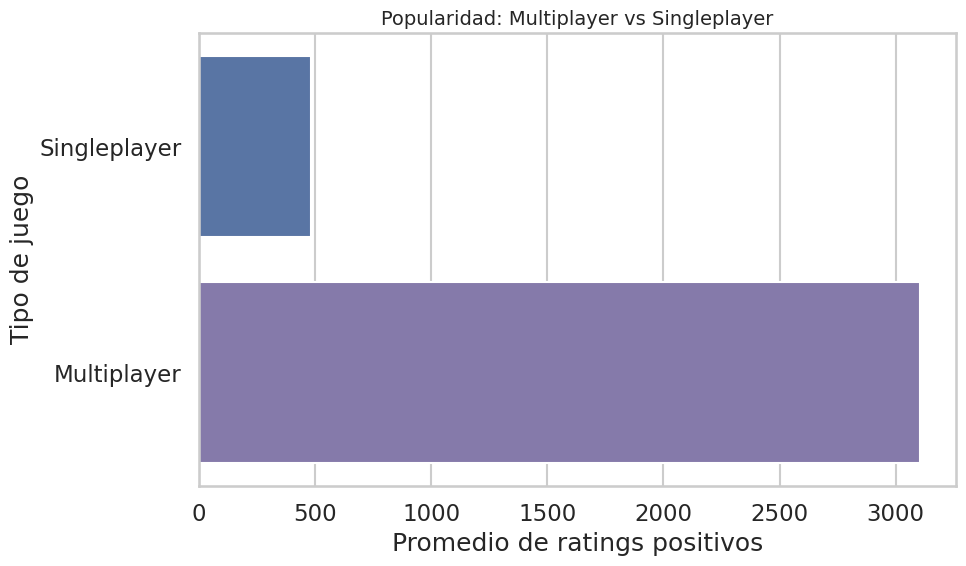

In [73]:
df['is_multiplayer'] = df['categories'].apply(
    lambda x: any('Multi' in cat for cat in x) if isinstance(x, list) else False
)

df['is_multiplayer'] = df['categories'].apply(
    lambda x: any('Multi' in cat for cat in x) if isinstance(x, list) else False
)

df_plot = df.groupby('is_multiplayer')['positive_ratings'].mean().reset_index()

df_plot['is_multiplayer'] = df_plot['is_multiplayer'].map({
    False: 'Singleplayer',
    True: 'Multiplayer'
})

sns.barplot(
    data=df_plot,
    y='is_multiplayer',
    x='positive_ratings',
    palette=['#4C72B0', '#8172B2']
)

plt.title('Popularidad: Multiplayer vs Singleplayer', fontsize=14)
plt.xlabel('Promedio de ratings positivos')
plt.ylabel('Tipo de juego')

plt.tight_layout()
plt.show()

### 3. ¿Qué etiquetas están más asociadas con videojuegos populares?

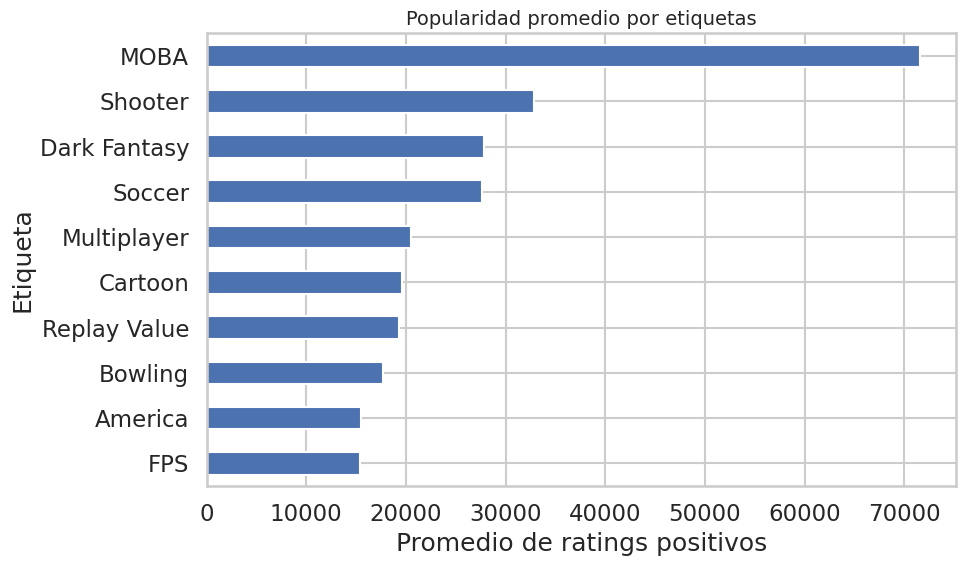

In [74]:
top_tags = df_tags.groupby('steamspy_tags')['positive_ratings'] \
    .mean() \
    .sort_values(ascending=True) \
    .tail(10)

top_tags.plot(kind='barh', color='#4C72B0')

plt.title('Popularidad promedio por etiquetas', fontsize=14)
plt.xlabel('Promedio de ratings positivos')
plt.ylabel('Etiqueta')

plt.tight_layout()
plt.show()

### 4. ¿Existe relación entre el tiempo de juego promedio y la popularidad de un videojuego?

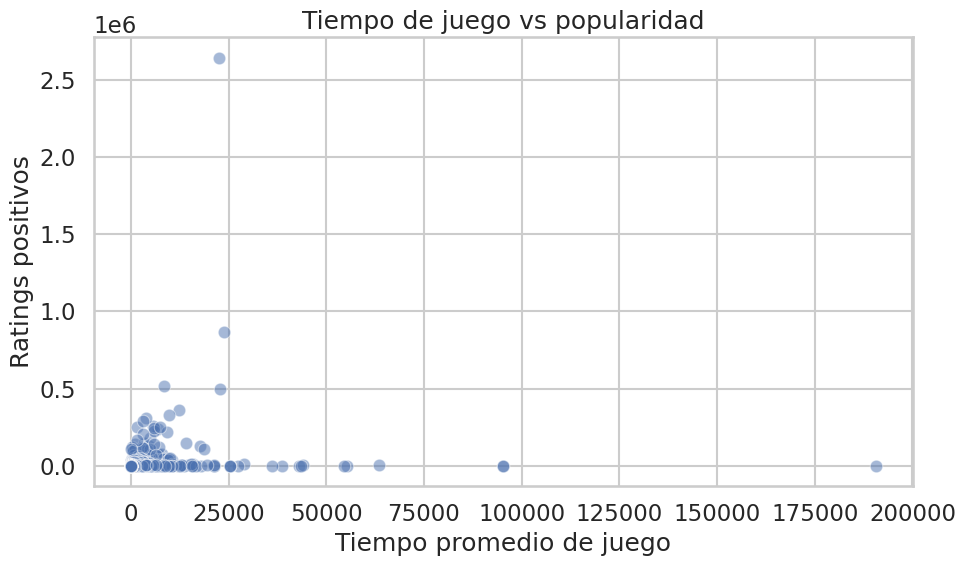

In [77]:
sns.scatterplot(
    x='average_playtime',
    y='positive_ratings',
    data=df,
    alpha=0.5
)

plt.title('Tiempo de juego vs popularidad')
plt.xlabel('Tiempo promedio de juego')
plt.ylabel('Ratings positivos')

plt.tight_layout()
plt.show()

### 5. ¿Qué géneros predominan en los videojuegos más exitosos?

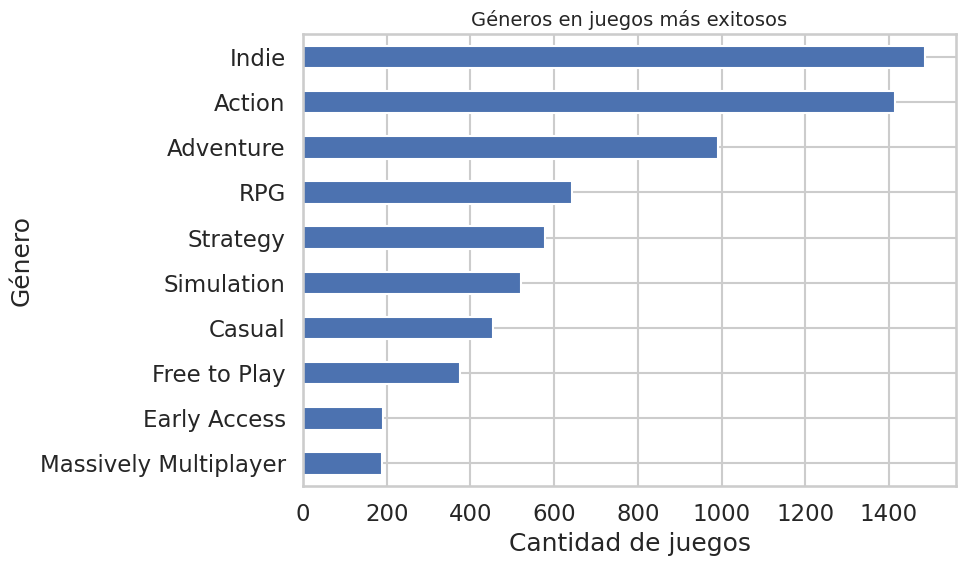

In [79]:
top_games = df[df['positive_ratings'] > df['positive_ratings'].quantile(0.9)]

top_genres = top_games.explode('genres')['genres'].value_counts().head(10).sort_values()

top_genres.plot(kind='barh', color='#4C72B0')

plt.title('Géneros en juegos más exitosos', fontsize=14)
plt.xlabel('Cantidad de juegos')
plt.ylabel('Género')

plt.tight_layout()
plt.show()

## 8. Conclusiones

El análisis descriptivo del dataset permitió identificar diversos patrones relevantes en el comportamiento de los videojuegos en la plataforma Steam.

En primer lugar, se observó que la mayoría de los videojuegos presentan precios bajos, con una distribución sesgada y presencia de valores atípicos, lo que indica que pocos juegos tienen precios significativamente altos.

Asimismo, se identificó que la popularidad, medida a través de los ratings positivos, está altamente concentrada en un pequeño grupo de videojuegos, mientras que la mayoría presenta niveles bajos de interacción.

El análisis bivariado y multivariado mostró que no existe una relación clara entre el precio y la popularidad, lo que sugiere que el éxito de un videojuego no depende directamente de su costo.

Por otro lado, variables como el género, las categorías y las etiquetas del juego sí presentan una influencia en la popularidad, destacando especialmente los juegos multijugador y géneros como MOBA, los cuales tienden a generar mayor interacción.

Finalmente, se observó que el dataset presenta distribuciones asimétricas y presencia de valores atípicos, lo que refleja un comportamiento típico de plataformas digitales donde pocos productos concentran la mayor parte de la actividad.